In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

In [2]:
train_part1 = pd.read_parquet("../ClearData/train_part1.parquet")

In [3]:
x = train_part1.drop(columns="target")
y = train_part1["target"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y) 

In [5]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

Train metrics:
Accuracy: 0.9626314975501592
Precision: 0.006483893000285212
Recall: 0.3975494707777266
F1-score: 0.01275968007562386
PR-AUC: 0.009187457813647165

Test metrics:
Accuracy: 0.9626927941967811
Precision: 0.006382298755498741
Recall: 0.3906789413118527
F1-score: 0.012559421415755693
PR-AUC: 0.007273961714400797

Confusion matrix


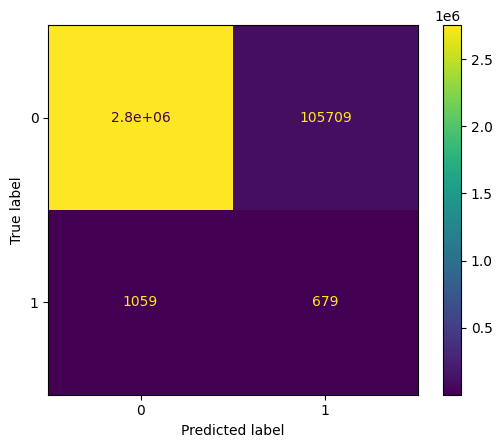

In [6]:
weights = {0: 1, 1: 500}
CatBoost4 = CatBoostClassifier(iterations=200, depth=4, class_weights=weights, verbose=False)
train_models(CatBoost4, x, X_test, y, y_test)

In [8]:
CatBoost4.save_model('../Models/Model_1.cbm')